<a href="https://colab.research.google.com/github/Shashank-Karanam/6thSem-ML-Lab/blob/main/1BM23CS312_Lab_9_AdaBoost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Build a AdaBoost classifier to classify Income dataset

Measure prediction score using n_estimators (10).

Now fine tune your model by changing number of trees in your classifier and identify what best score you can get using how
many trees

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('income.csv')
print("Shape:", df.shape)
print(df.head())
print("\nColumns:", df.columns.tolist())
print("\nTarget value counts:\n", df['income_level'].value_counts())

Shape: (48842, 7)
   age  fnlwgt  education_num  capital_gain  capital_loss  hours_per_week  \
0   39   77516             13          2174             0              40   
1   50   83311             13             0             0              13   
2   38  215646              9             0             0              40   
3   53  234721              7             0             0              40   
4   28  338409             13             0             0              40   

   income_level  
0             0  
1             0  
2             0  
3             0  
4             0  

Columns: ['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week', 'income_level']

Target value counts:
 income_level
0    37155
1    11687
Name: count, dtype: int64


In [ ]:
# Confirm no object (string) columns remain
print(df.dtypes)
print("\nNull values:\n", df.isnull().sum())

age               int64
fnlwgt            int64
education_num     int64
capital_gain      int64
capital_loss      int64
hours_per_week    int64
income_level      int64
dtype: object

Null values:
 age               0
fnlwgt            0
education_num     0
capital_gain      0
capital_loss      0
hours_per_week    0
income_level      0
dtype: int64


In [ ]:
X = df.drop('income_level', axis=1)
y = df['income_level']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")

Train size: (39073, 6), Test size: (9769, 6)


In [ ]:
base = DecisionTreeClassifier(max_depth=1)
ada_10 = AdaBoostClassifier(
    estimator=base,
    n_estimators=10,
    random_state=42
)
ada_10.fit(X_train, y_train)
y_pred_10 = ada_10.predict(X_test)

acc_10 = accuracy_score(y_test, y_pred_10)
print(f"Accuracy with n_estimators=10 : {acc_10:.4f}")

Accuracy with n_estimators=10 : 0.8182


In [ ]:
estimator_range = [10, 25, 50, 75, 100, 150, 200]
scores = []

for n in estimator_range:
    clf = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1),
        n_estimators=n,
        random_state=42
    )
    clf.fit(X_train, y_train)
    acc = accuracy_score(y_test, clf.predict(X_test))
    scores.append(acc)
    print(f"n_estimators={n:3d}  →  accuracy={acc:.4f}")

best_n   = estimator_range[np.argmax(scores)]
best_acc = max(scores)
print(f"\nBest score : {best_acc:.4f}  at n_estimators = {best_n}")

n_estimators= 10  →  accuracy=0.8182
n_estimators= 25  →  accuracy=0.8297
n_estimators= 50  →  accuracy=0.8327
n_estimators= 75  →  accuracy=0.8335
n_estimators=100  →  accuracy=0.8328
n_estimators=150  →  accuracy=0.8329
n_estimators=200  →  accuracy=0.8332

Best score : 0.8335  at n_estimators = 75


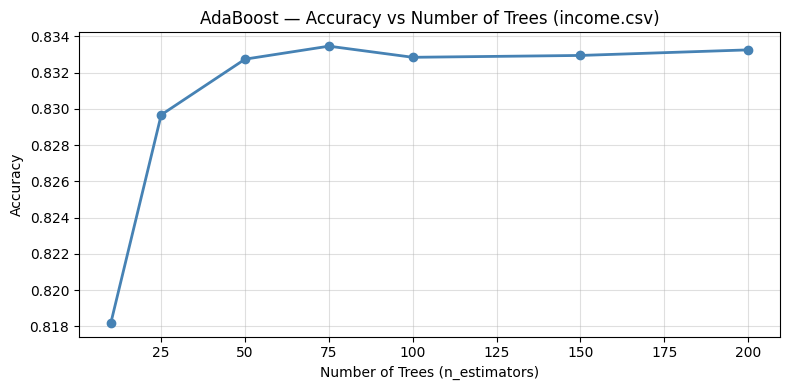

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(estimator_range, scores, marker='o', color='steelblue', linewidth=2)
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('Accuracy')
plt.title('AdaBoost — Accuracy vs Number of Trees (income.csv)')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('adaboost_accuracy.png', dpi=120)
plt.show()

In [ ]:
best_clf = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=best_n,
    random_state=42
)
best_clf.fit(X_train, y_train)
y_best_pred = best_clf.predict(X_test)

cm = confusion_matrix(y_test, y_best_pred)
print("Confusion Matrix:")
print(cm)
print(f"\nBest Accuracy : {accuracy_score(y_test, y_best_pred):.4f}")
print(f"Best n_estimators : {best_n}")

Confusion Matrix:
[[7131  283]
 [1344 1011]]

Best Accuracy : 0.8335
Best n_estimators : 75


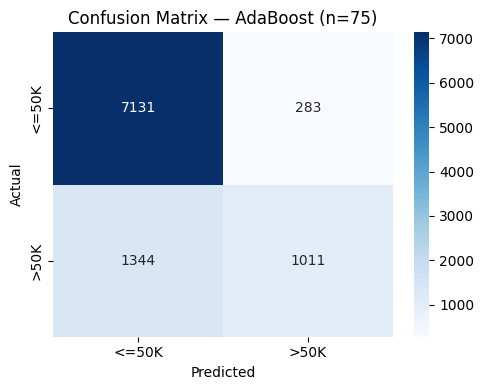

In [ ]:
import seaborn as sns
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['<=50K', '>50K'],
            yticklabels=['<=50K', '>50K'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix — AdaBoost (n={best_n})')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=120)
plt.show()